# Initial feature preprocessing

## Overview

This notebook performs the initial preprocessing steps that are shared across 
both the classification and regression modeling pipelines.

The following steps are applied:

1. **Feature engineering from date feature**

2. **Correlation analysis** 

## 1. Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

company_colors = {"NVDA": "#4DB6AC", "AMD": "#BA68C8", "INTC": "#5C9BD5"}
sns.set_theme(style="ticks", font_scale=1.1)

df = pd.read_csv('datasets/final/final_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

TARGET_COLS   = ['target_direction','target_volatility_10d']
META_COLS     = ['date', 'ticker', 'company']

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (7413, 65)
Columns: ['date', 'company', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'sma_10', 'sma_20', 'wma_10', 'rsi_14', 'macd', 'macd_signal', 'stoch_k', 'stoch_d', 'williams_r', 'roc_10', 'mom_10', 'trix', 'bb_upper', 'bb_middle', 'bb_lower', 'atr_14', 'natr', 'hist_vol_20', 'std_20', 'obv', 'ad', 'adosc', 'log_volume', 'volume_chng', 'log_return', 'return_1d', 'return_2d', 'return_5d', 'hl_ratio', 'rv_daily', 'rv_weekly', 'rv_monthly', 'hv_lag_1', 'hv_lag_5', 'hv_lag_22', 'target_direction', 'target_volatility_10d', 'target_volume_ratio', 'FEDFUNDS', 'DGS10', 'DGS2', 'yield_spread', 'VIX', 'nasdaq_return', 'soxx_return', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom', 'reddit_sentiment', 'reddit_post_count', 'reddit_comment_count', 'news_sentiment', 'news_count']


## 2. Feature engineering from date feature

Raw date values are not suitable as model inputs because treating dates as ordinary numerical values may encourage the model to learn relationships tied to specific points in time rather than underlying market dynamics, potentially reducing its ability to generalize to future observations.

To capture the cyclical nature of time, month and day-of-week are encoded using sine and cosine transformations. For a variable with period $T$, the encoding is defined as:

$$x_{\sin} = \sin\left(\frac{2\pi \cdot x}{T}\right), \quad x_{\cos} = \cos\left(\frac{2\pi \cdot x}{T}\right)$$

This maps each value onto a unit circle, preserving the cyclical structure of temporal variables. As a result, values located near cycle boundaries (e.g. December and January) are represented as neighboring points in the transformed space. Two components are required because sine alone is not injective. For example, March and September share the same sine value. Together, sine and cosine uniquely determine each position within the cycle.

The following temporal features are constructed:
- **`month_sin`, `month_cos`** — cyclical encoding of the calendar 
  month ($T = 12$), capturing seasonal patterns in market behavior
- **`dow_sin`, `dow_cos`** — cyclical encoding of the day of week 
  ($T = 5$, trading days only: Monday=0 to Friday=4), capturing 
  within-week patterns such as the Monday effect

In [2]:
# Month — period T=12
df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)

# Day of week — period T=5 (trading days: Monday=0, Friday=4)
df['dow_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 5)
df['dow_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 5)

print('Temporal features added:')
print(df[['date', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']].head(10))

Temporal features added:
        date     month_sin  month_cos   dow_sin   dow_cos
0 2016-05-31  5.000000e-01  -0.866025  0.951057  0.309017
1 2016-06-01  1.224647e-16  -1.000000  0.587785 -0.809017
2 2016-06-02  1.224647e-16  -1.000000 -0.587785 -0.809017
3 2016-06-03  1.224647e-16  -1.000000 -0.951057  0.309017
4 2016-06-06  1.224647e-16  -1.000000  0.000000  1.000000
5 2016-06-07  1.224647e-16  -1.000000  0.951057  0.309017
6 2016-06-08  1.224647e-16  -1.000000  0.587785 -0.809017
7 2016-06-09  1.224647e-16  -1.000000 -0.587785 -0.809017
8 2016-06-10  1.224647e-16  -1.000000 -0.951057  0.309017
9 2016-06-13  1.224647e-16  -1.000000  0.000000  1.000000


## 3. Correlation analysis

Since most technical indicators are derived from the same underlying stock
price series, a substantial degree of correlation between predictors is
expected. Correlation analysis was performed on the complete dataset to obtain an initial understanding of relationships between predictors and identify potentially redundant variables.

*Features exhibiting very high pairwise correlations are marked as candidates
for further inspection during the modeling stage.*

In [3]:
feature_cols = [
    col for col in df.columns
    if col not in META_COLS + TARGET_COLS
]

print(f'Number of features: {len(feature_cols)}')

Number of features: 65


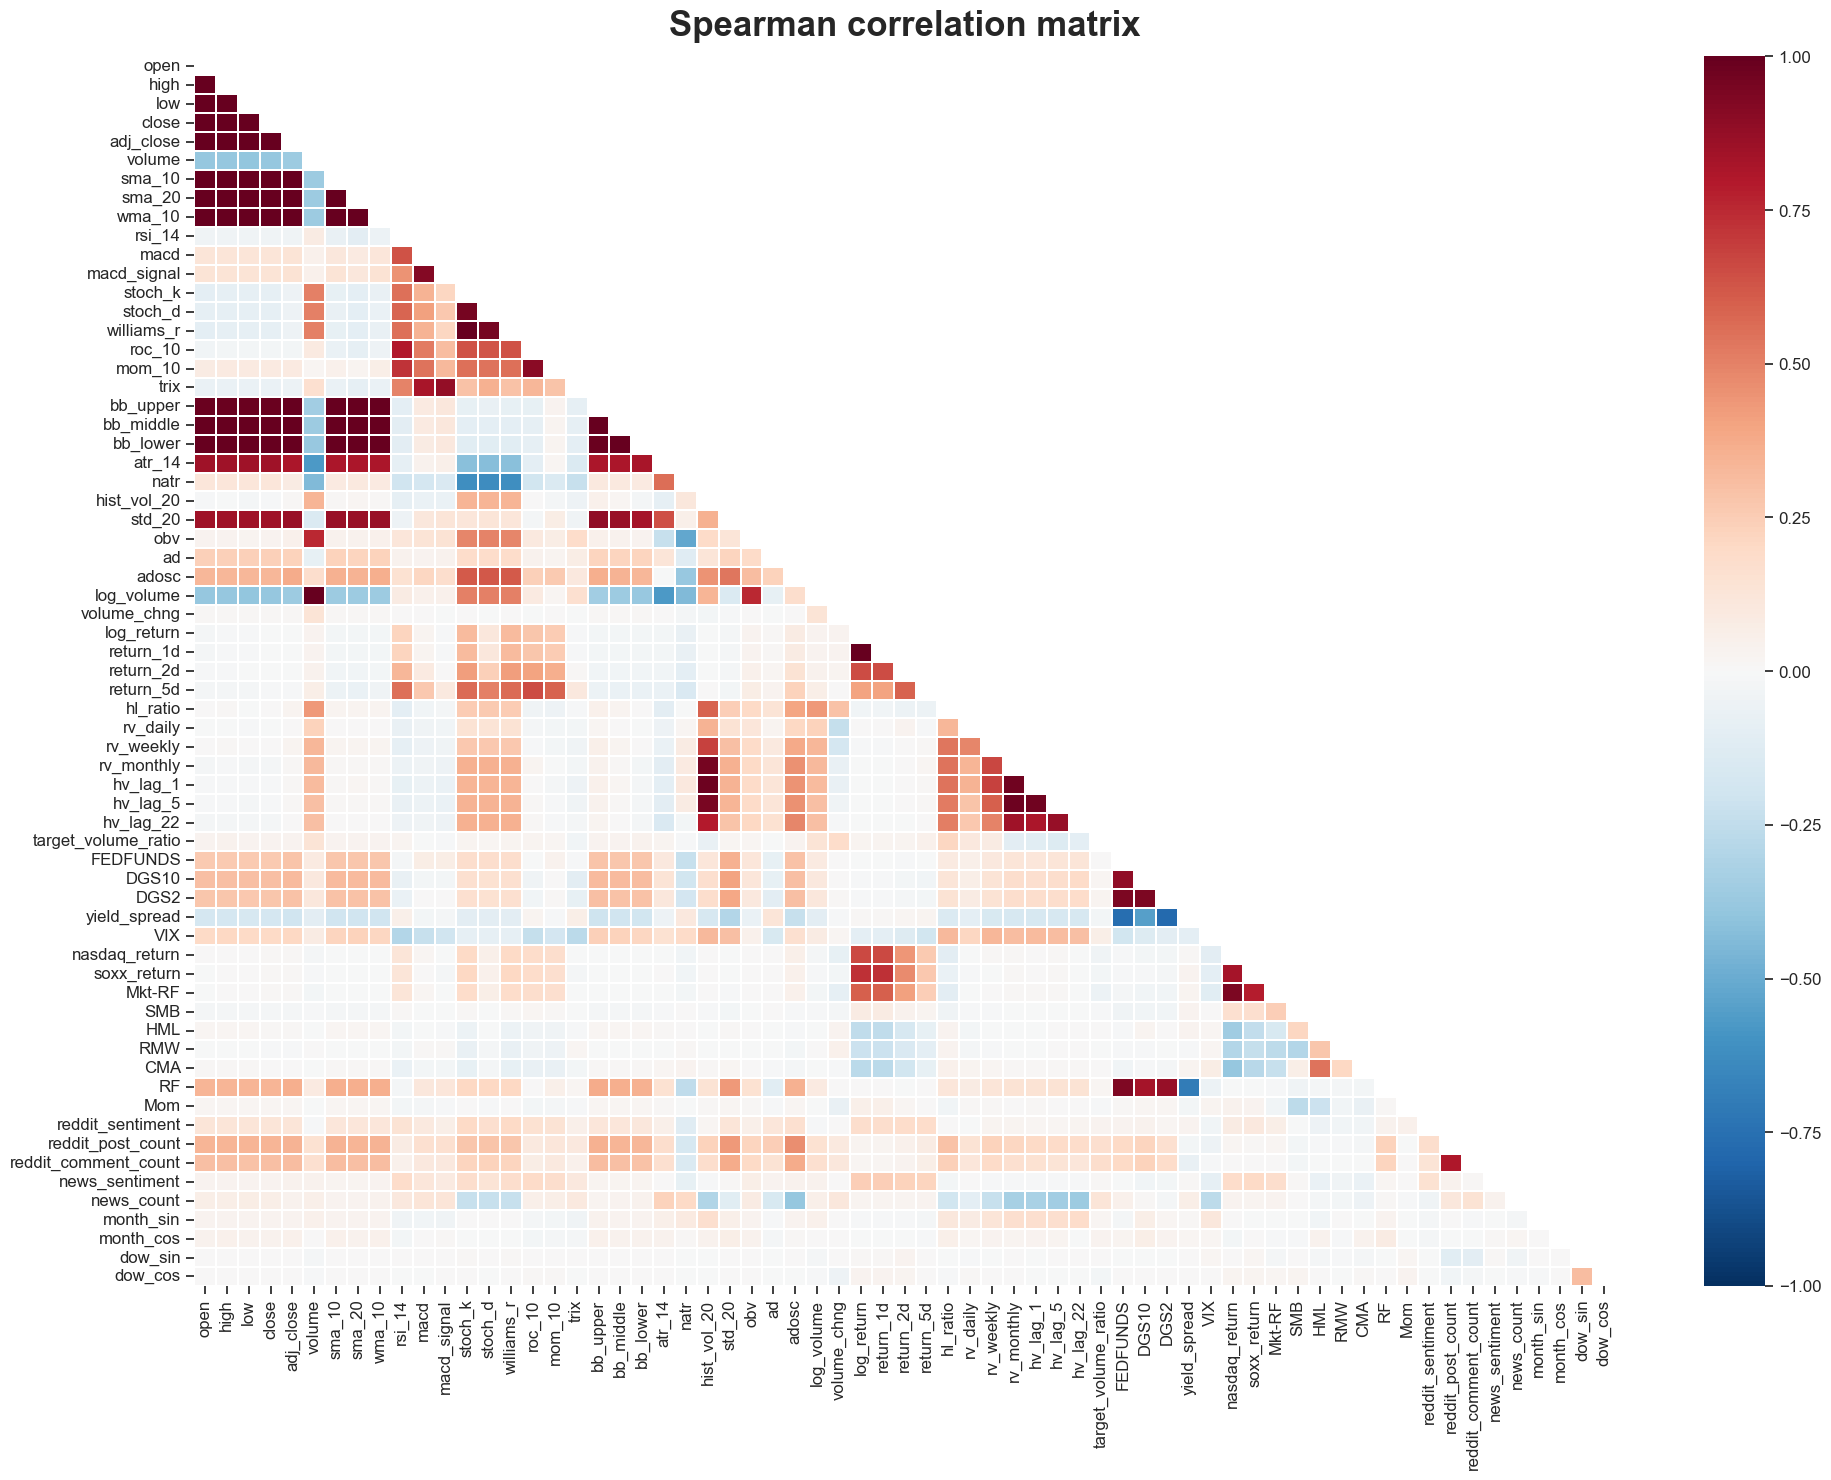

In [4]:
corr_matrix = df[feature_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(20, 15))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=False,
    ax=ax
)

ax.set_title('Spearman correlation matrix',
             fontsize=25, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [5]:
corr_pairs = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr = (
    corr_pairs
    .reset_index()
    .rename(columns={
        'level_0': 'feature_1',
        'level_1': 'feature_2',
        0: 'correlation'
    })
)

pd.set_option('display.max_rows', None)

high_corr[high_corr["correlation"]>0.90]

,feature_1,feature_2,correlation
0,log_return,return_1d,1.000000
1,sma_20,bb_middle,1.000000
2,stoch_k,williams_r,1.000000
3,volume,log_volume,1.000000
4,low,close,0.999826
5,sma_10,wma_10,0.999821
6,open,low,0.999820
7,open,high,0.999811
8,high,close,0.999808
9,high,low,0.999743


*Several near-perfect correlations were identified among predictors. Most of them arise from indicators that are mathematically related or derived from the same underlying price series. Examples include Stochastic %K and Williams %R, SMA20 and the Bollinger middle band, as well as log returns and one-day percentage returns.*

In [6]:
df.to_csv('datasets/final/initial_processed_dataset.csv', index=False)

In [7]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("feature_preprocessing")

with mlflow.start_run(run_name="initial_feature_preprocessing"):

    mlflow.log_param("final_feature_count", len(feature_cols))
    mlflow.log_metric(
        "num_high_corr_pairs",
        len(high_corr[high_corr["correlation"] > 0.95])
    )


    print("Run successfully logged.")

2026/06/05 13:00:10 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Run successfully logged.
